In [3]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files

uploaded = files.upload()

Saving thyroid+disease.zip to thyroid+disease (1).zip


In [5]:
import zipfile

with zipfile.ZipFile('thyroid+disease (1).zip', 'r') as zip_ref:
    zip_ref.extractall('thyroid_dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [6]:
import os

for root, dirs, files in os.walk("thyroid_dataset"):
    for file in files:
        print(os.path.join(root, file))

thyroid_dataset/sick.names
thyroid_dataset/allbp.names
thyroid_dataset/allbp.test
thyroid_dataset/new-thyroid.data
thyroid_dataset/thyroid0387.data
thyroid_dataset/hypothyroid.data
thyroid_dataset/ann-Readme
thyroid_dataset/allrep.data
thyroid_dataset/dis.names
thyroid_dataset/sick.test
thyroid_dataset/ann-test.data
thyroid_dataset/sick-euthyroid.data
thyroid_dataset/allhypo.test
thyroid_dataset/thyroid0387.names
thyroid_dataset/HELLO
thyroid_dataset/allhyper.test
thyroid_dataset/new-thyroid.names
thyroid_dataset/allbp.data
thyroid_dataset/allhypo.data
thyroid_dataset/allhyper.names
thyroid_dataset/allrep.names
thyroid_dataset/thyroid.theory
thyroid_dataset/sick-euthyroid.names
thyroid_dataset/ann-thyroid.names
thyroid_dataset/Index
thyroid_dataset/ann-train.data
thyroid_dataset/dis.test
thyroid_dataset/hypothyroid.names
thyroid_dataset/dis.data
thyroid_dataset/sick.data
thyroid_dataset/allhypo.names
thyroid_dataset/allhyper.data
thyroid_dataset/allrep.test
thyroid_dataset/costs/ann-th

In [7]:
columns = [
    "Class",
    "T3_resin_uptake",
    "Total_serum_thyroxine",
    "Total_serum_triiodothyronine",
    "Basal_TSH",
    "TSH_after_TRH"
]

df = pd.read_csv(
    "thyroid_dataset/new-thyroid.data",
    sep=",", # Changed separator from r"\s+" to ","
    header=None,
    names=columns
)

# Ensure the 'Class' column is numeric, as it represents categories 1, 2, 3
df['Class'] = df['Class'].astype(int)

df.head()

,Class,T3_resin_uptake,Total_serum_thyroxine,Total_serum_triiodothyronine,Basal_TSH,TSH_after_TRH
0,1,107,10.1,2.2,0.9,2.7
1,1,113,9.9,3.1,2.0,5.9
2,1,127,12.9,2.4,1.4,0.6
3,1,109,5.3,1.6,1.4,1.5
4,1,105,7.3,1.5,1.5,-0.1


In [8]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(215, 6)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         215 non-null    int64  
 1   T3_resin_uptake               215 non-null    int64  
 2   Total_serum_thyroxine         215 non-null    float64
 3   Total_serum_triiodothyronine  215 non-null    float64
 4   Basal_TSH                     215 non-null    float64
 5   TSH_after_TRH                 215 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 10.2 KB


In [10]:
df.head()

,Class,T3_resin_uptake,Total_serum_thyroxine,Total_serum_triiodothyronine,Basal_TSH,TSH_after_TRH
0,1,107,10.1,2.2,0.9,2.7
1,1,113,9.9,3.1,2.0,5.9
2,1,127,12.9,2.4,1.4,0.6
3,1,109,5.3,1.6,1.4,1.5
4,1,105,7.3,1.5,1.5,-0.1


In [11]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
Class                           0
T3_resin_uptake                 0
Total_serum_thyroxine           0
Total_serum_triiodothyronine    0
Basal_TSH                       0
TSH_after_TRH                   0
dtype: int64


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Records =", duplicates)

Duplicate Records = 0


In [13]:
df.describe()

,Class,T3_resin_uptake,Total_serum_thyroxine,Total_serum_triiodothyronine,Basal_TSH,TSH_after_TRH
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,1.441860,109.595349,9.804651,2.050233,2.880000,4.199070
std,0.726737,13.145447,4.697362,1.419486,6.118031,8.070519
min,1.000000,65.000000,0.500000,0.200000,0.100000,-0.700000
25%,1.000000,103.000000,7.100000,1.350000,1.000000,0.550000
50%,1.000000,110.000000,9.200000,1.700000,1.300000,2.000000
75%,2.000000,117.500000,11.300000,2.200000,1.700000,4.100000
max,3.000000,144.000000,25.300000,10.000000,56.400000,56.300000


In [14]:
class_names = {
    1:"Normal",
    2:"Hyperthyroidism",
    3:"Hypothyroidism"
}

class_names

{1: 'Normal', 2: 'Hyperthyroidism', 3: 'Hypothyroidism'}

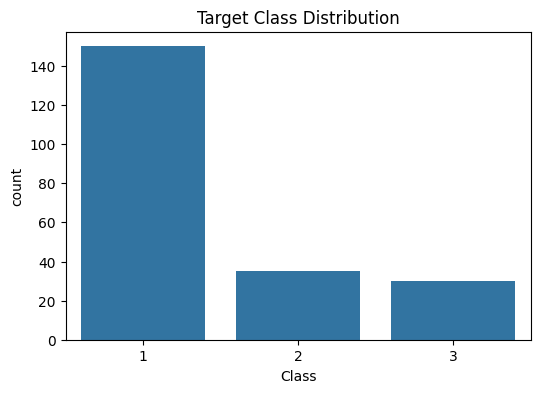

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Target Class Distribution")

plt.show()

In [16]:
print(df["Class"].value_counts())

Class
1    150
2     35
3     30
Name: count, dtype: int64


In [17]:
class_percent = df["Class"].value_counts(normalize=True)*100

print(class_percent)

Class
1    69.767442
2    16.279070
3    13.953488
Name: proportion, dtype: float64


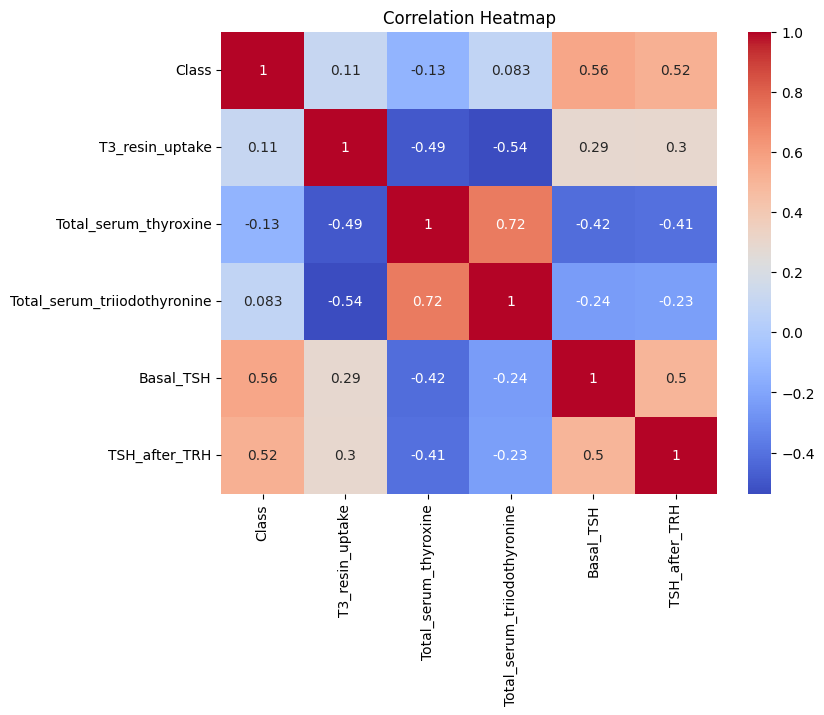

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

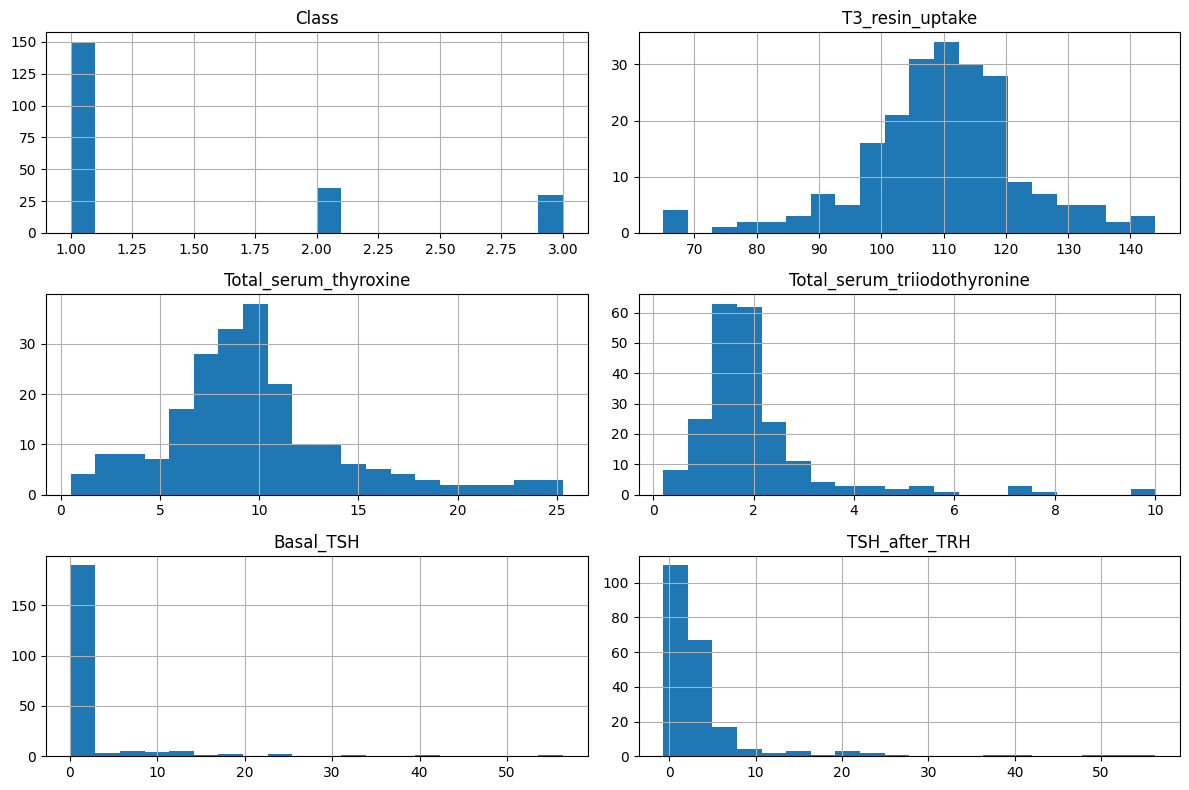

In [19]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

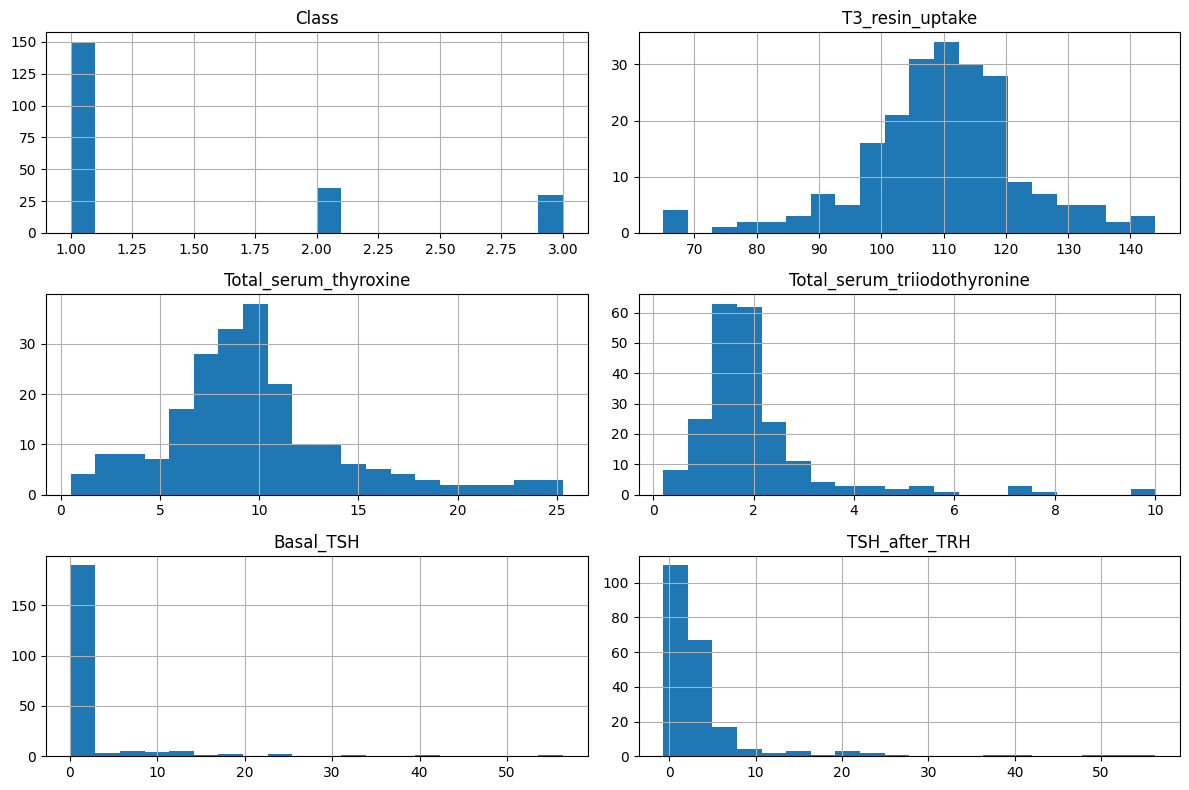

In [20]:
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

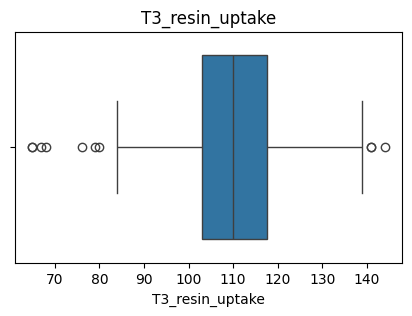

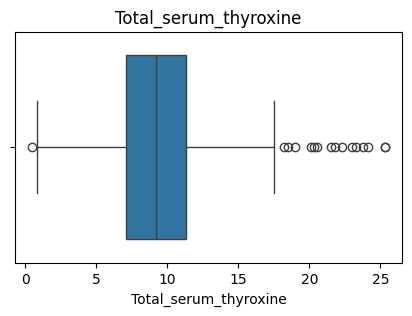

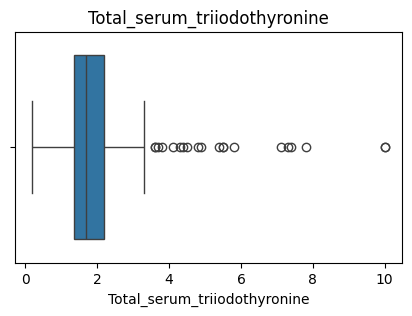

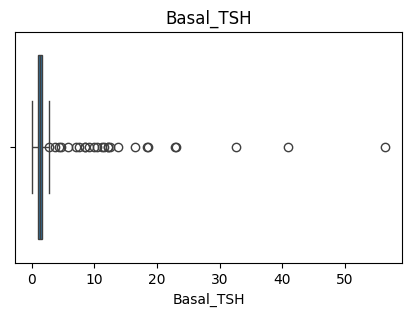

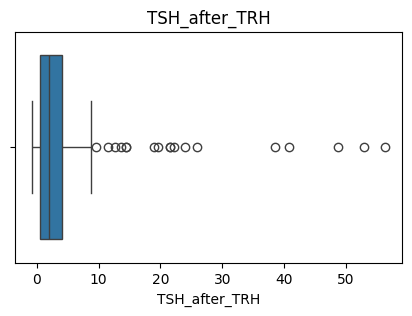

In [21]:
for col in df.columns[1:]:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [22]:
X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)

print(y.shape)

(215, 5)
(215,)


In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape")

print(X_train.shape)

print("\nTesting Shape")

print(X_test.shape)

Training Shape
(172, 5)

Testing Shape
(43, 5)


In [25]:
print("Training Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

Training Class Distribution
Class
1    120
2     28
3     24
Name: count, dtype: int64

Testing Class Distribution
Class
1    30
2     7
3     6
Name: count, dtype: int64


In [26]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "SVM":
        SVC(),

    "KNN":
        KNeighborsClassifier()
}



Logistic Regression
Accuracy = 100.0 %

Classification Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         6

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



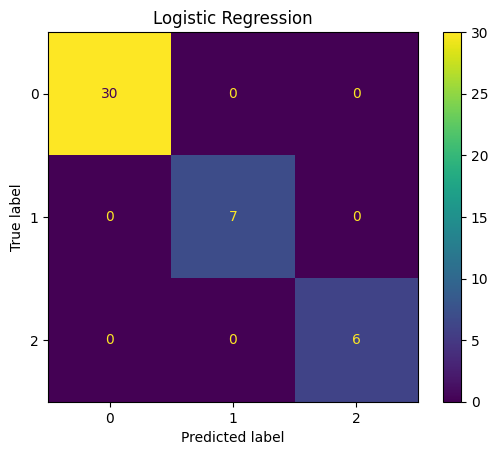



Decision Tree
Accuracy = 95.35 %

Classification Report
              precision    recall  f1-score   support

           1       0.97      0.97      0.97        30
           2       0.86      0.86      0.86         7
           3       1.00      1.00      1.00         6

    accuracy                           0.95        43
   macro avg       0.94      0.94      0.94        43
weighted avg       0.95      0.95      0.95        43



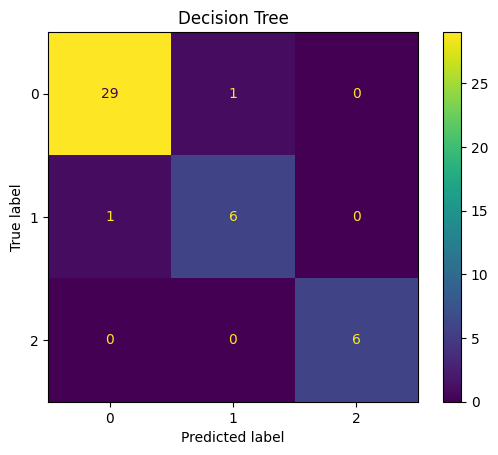



Random Forest
Accuracy = 100.0 %

Classification Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         6

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



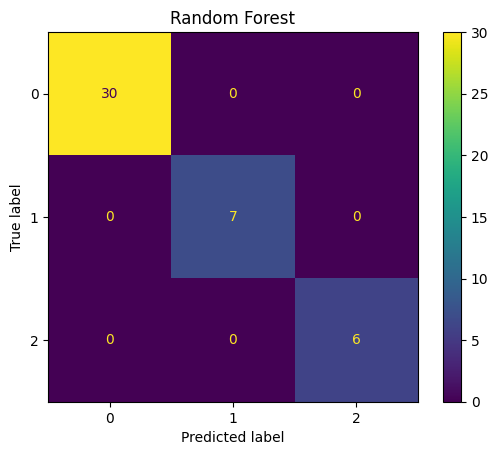



SVM
Accuracy = 97.67 %

Classification Report
              precision    recall  f1-score   support

           1       0.97      1.00      0.98        30
           2       1.00      1.00      1.00         7
           3       1.00      0.83      0.91         6

    accuracy                           0.98        43
   macro avg       0.99      0.94      0.96        43
weighted avg       0.98      0.98      0.98        43



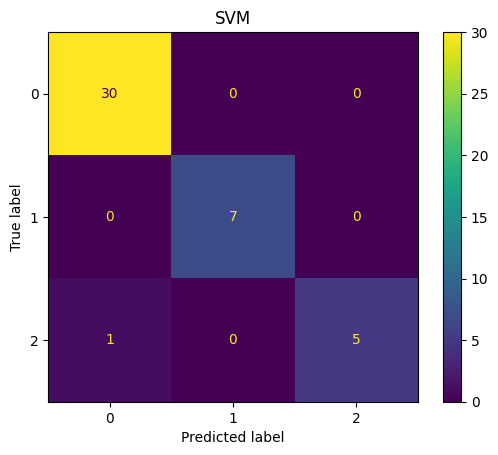



KNN
Accuracy = 90.7 %

Classification Report
              precision    recall  f1-score   support

           1       0.88      1.00      0.94        30
           2       1.00      0.71      0.83         7
           3       1.00      0.67      0.80         6

    accuracy                           0.91        43
   macro avg       0.96      0.79      0.86        43
weighted avg       0.92      0.91      0.90        43



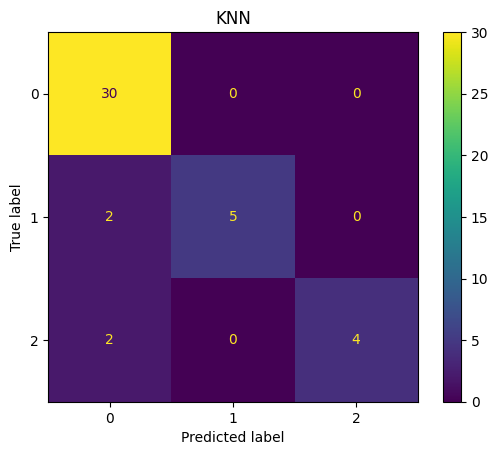

In [27]:
results = []

for name, model in models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Accuracy =", round(acc*100,2), "%")

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    results.append(
        [name, acc]
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(cm)

    disp.plot()

    plt.title(name)

    plt.show()

In [28]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df["Accuracy"] = results_df["Accuracy"]*100

results_df

,Model,Accuracy
0,Logistic Regression,100.000000
1,Decision Tree,95.348837
2,Random Forest,100.000000
3,SVM,97.674419
4,KNN,90.697674


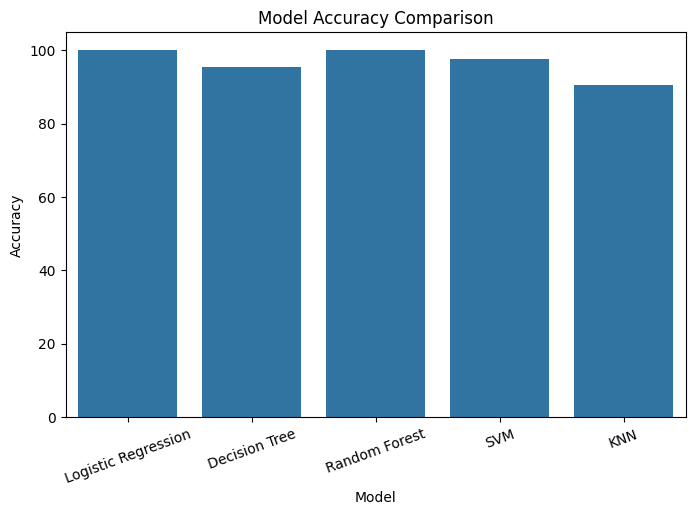

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

In [30]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy                  100.0
Name: 0, dtype: object


In [31]:
rf = RandomForestClassifier(
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=cv
)

print("Cross Validation Scores")

print(scores)

print("\nAverage Accuracy")

print(scores.mean())

Cross Validation Scores
[0.97674419 0.95348837 1.         0.95348837 1.        ]

Average Accuracy
0.9767441860465116


In [32]:
rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
1         Total_serum_thyroxine    0.416892
4                 TSH_after_TRH    0.204096
3                     Basal_TSH    0.175233
2  Total_serum_triiodothyronine    0.148121
0               T3_resin_uptake    0.055658


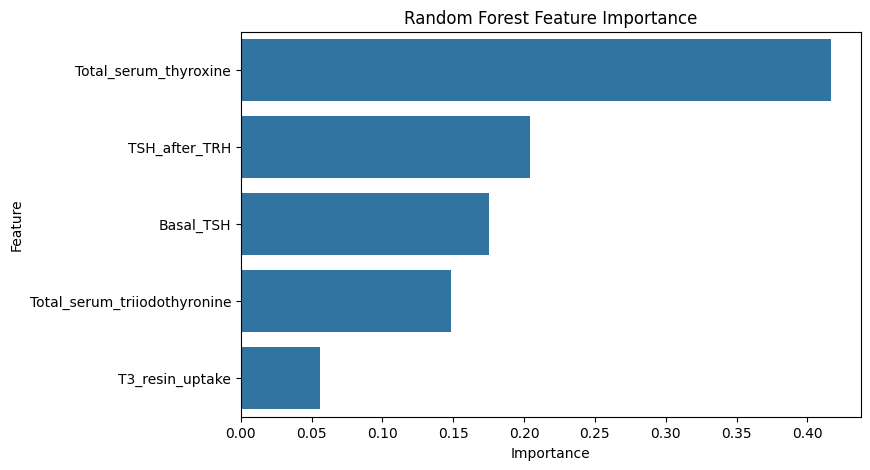

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [34]:
print("Feature Columns:")
print(df.columns.tolist())

print("\nTarget Column:")
print("Class")

Feature Columns:
['Class', 'T3_resin_uptake', 'Total_serum_thyroxine', 'Total_serum_triiodothyronine', 'Basal_TSH', 'TSH_after_TRH']

Target Column:
Class


In [35]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5
    )

    print(name)
    print("Mean CV Accuracy:", scores.mean())
    print("-"*40)

Logistic Regression
Mean CV Accuracy: 0.9488372093023255
----------------------------------------
Decision Tree
Mean CV Accuracy: 0.9348837209302324
----------------------------------------
Random Forest
Mean CV Accuracy: 0.9581395348837208
----------------------------------------
SVM
Mean CV Accuracy: 0.9581395348837208
----------------------------------------
KNN
Mean CV Accuracy: 0.9395348837209301
----------------------------------------


In [36]:
print(df.shape)

(215, 6)


In [37]:
print("Feature Columns:")
print(X.columns)

print("\nTarget Variable:")
print("Class")

Feature Columns:
Index(['T3_resin_uptake', 'Total_serum_thyroxine',
       'Total_serum_triiodothyronine', 'Basal_TSH', 'TSH_after_TRH'],
      dtype='object')

Target Variable:
Class


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                        Feature  Importance
1         Total_serum_thyroxine    0.416892
4                 TSH_after_TRH    0.204096
3                     Basal_TSH    0.175233
2  Total_serum_triiodothyronine    0.148121
0               T3_resin_uptake    0.055658


In [40]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (172, 5)
Testing Shape: (43, 5)


In [41]:
accuracy_df = results_df.copy()

print(accuracy_df)

                 Model    Accuracy
0  Logistic Regression  100.000000
1        Decision Tree   95.348837
2        Random Forest  100.000000
3                  SVM   97.674419
4                  KNN   90.697674
